# Netflix Content Strategy — Exploratory Data Analysis

**Business Problem:** Analyse Netflix's content library to generate insights that help decide which type of shows/movies to produce and how to grow the business in different countries.

**Dataset:** `netflix.csv` — 6200+ titles with cast, directors, countries, genres, ratings and release details

**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn

---

## 1. Problem Statement & Basic Metrics

Key business questions this analysis answers:
- What type of content performs well in which countries?
- How has Netflix content production changed over the years?
- What is the best time to launch a TV show?
- Which actors and directors dominate Netflix content?
- Should Netflix focus more on Movies or TV Shows going forward?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
# Load single dataset
df = pd.read_csv(r"netflix.csv")
print('Shape:', df.shape)
df.head()

Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# Basic metrics
print('Total titles     :', df.shape[0])
print('Total features   :', df.shape[1])
print('Movies           :', df[df['type']=='Movie'].shape[0])
print('TV Shows         :', df[df['type']=='TV Show'].shape[0])
print('Release yr range :', df['release_year'].min(), '-', df['release_year'].max())
print('Unique ratings   :', df['rating'].nunique())

Total titles     : 8807
Total features   : 12
Movies           : 6131
TV Shows         : 2676
Release yr range : 1925 - 2021
Unique ratings   : 17


## 2. Data Types, Categorical Conversion, Missing Values & Statistical Summary

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
# Convert categorical columns
cat_cols = ['type', 'rating']
for col in cat_cols:
    df[col] = df[col].astype('category')
print('Converted to category dtype:', cat_cols)

Converted to category dtype: ['type', 'rating']


In [6]:
# Missing value analysis
missing = df.isnull().sum()
missing_pct = round(df.isnull().sum() / df.shape[0] * 100, 2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}).sort_values('Missing %', ascending=False)

,Missing Count,Missing %
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00
title,0,0.00
release_year,0,0.00


In [7]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


## 3. Non-Graphical Analysis — Value Counts & Unique Attributes

In [8]:
print('=== Content Type ===')
print(df['type'].value_counts())

print('\n=== Top 10 Ratings ===')
print(df['rating'].value_counts().head(10))

print('\n=== Top 10 Release Years ===')
print(df['release_year'].value_counts().head(10))

=== Content Type ===
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

=== Top 10 Ratings ===
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

=== Top 10 Release Years ===
release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64


In [9]:
# Unique value count per column
for col in df.columns:
    print(f'{col:25s}: {df[col].nunique()} unique values')

show_id                  : 8807 unique values
type                     : 2 unique values
title                    : 8807 unique values
director                 : 4528 unique values
cast                     : 7692 unique values
country                  : 748 unique values
date_added               : 1767 unique values
release_year             : 74 unique values
rating                   : 17 unique values
duration                 : 220 unique values
listed_in                : 514 unique values
description              : 8775 unique values


In [10]:
# Top 15 countries
top_countries = (
    df['country'].dropna()
    .str.split(', ')
    .explode()
    .str.strip()
    .value_counts()
    .head(15)
)
print('Top 15 content-producing countries:')
print(top_countries)

Top 15 content-producing countries:
country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
China              162
Australia          160
Egypt              117
Turkey             113
Hong Kong          105
Name: count, dtype: int64


In [11]:
# Top 15 genres
top_genres = (
    df['listed_in'].dropna()
    .str.split(', ')
    .explode()
    .str.strip()
    .value_counts()
    .head(15)
)
print('Top 15 genres:')
print(top_genres)

Top 15 genres:
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Name: count, dtype: int64


In [12]:
# Top 10 directors
top_dirs = (
    df['director'].dropna()
    .str.split(', ')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)
print('Top 10 directors:')
print(top_dirs)

Top 10 directors:
director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Jay Chapman            12
Youssef Chahine        12
Martin Scorsese        12
Name: count, dtype: int64


In [13]:
# Top 10 actors
top_cast = (
    df['cast'].dropna()
    .str.split(', ')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)
print('Top 10 actors:')
print(top_cast)

Top 10 actors:
cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Paresh Rawal        28
Name: count, dtype: int64


## 4. Visual Analysis

### 4.1 Continuous Variables

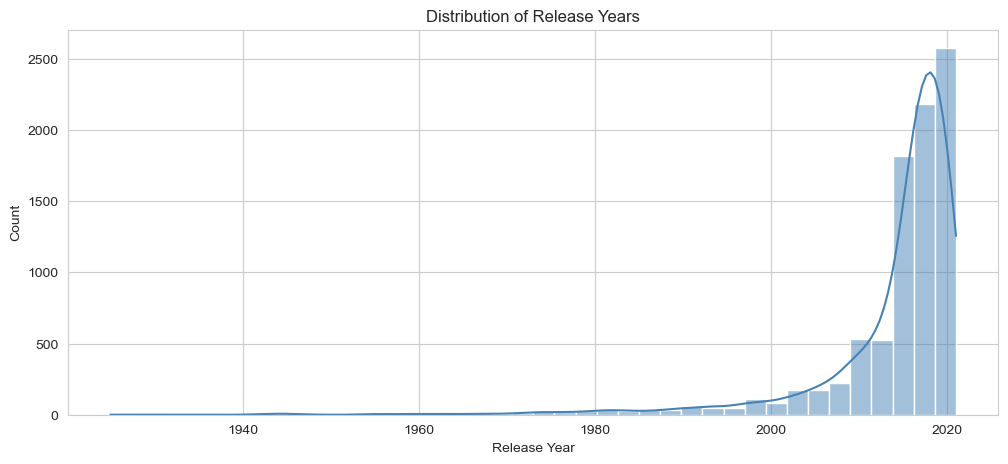

In [14]:
# Release year distribution
plt.figure(figsize=(12, 5))
sns.histplot(df['release_year'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()
# Insight: Content production accelerated sharply post-2015, peaking around 2018-2019

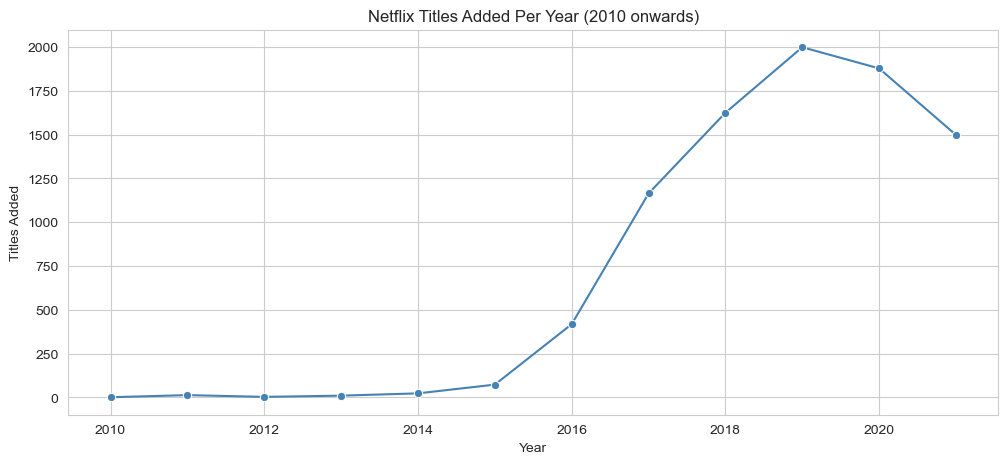

In [15]:
# Content added per year
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

yearly = df[df['year_added'] >= 2010].groupby('year_added')['show_id'].count()

plt.figure(figsize=(12, 5))
sns.lineplot(x=yearly.index, y=yearly.values, marker='o', color='steelblue')
plt.title('Netflix Titles Added Per Year (2010 onwards)')
plt.xlabel('Year')
plt.ylabel('Titles Added')
plt.show()
# Insight: Massive growth 2015-2019; dip in 2020 likely due to COVID production delays

In [16]:
# Movie duration distribution
movies = df[df['type'] == 'Movie'].copy()
movies['duration_minutes'] = pd.to_numeric(movies['duration_minutes'], errors='coerce')

plt.figure(figsize=(12, 5))
sns.histplot(movies['duration_minutes'].dropna(), bins=40, kde=True, color='coral')
plt.title('Movie Duration Distribution (minutes)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.show()
# Insight: Most movies are 80-120 minutes — standard feature film length

KeyError: 'duration_minutes'

### 4.2 Categorical Variables

In [ ]:
# Movies vs TV Shows pie chart
plt.figure(figsize=(6, 6))
counts = df['type'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',
        startangle=90, colors=['steelblue', 'coral'])
plt.title('Movies vs TV Shows on Netflix')
plt.show()
# Insight: ~70% Movies, ~30% TV Shows

In [ ]:
# Rating distribution
plt.figure(figsize=(12, 5))
rc = df['rating'].value_counts()
sns.barplot(x=rc.values, y=rc.index, palette='Blues_r')
plt.title('Content Rating Distribution')
plt.xlabel('Number of Titles')
plt.ylabel('Rating')
plt.show()
# Insight: TV-MA and TV-14 dominate — Netflix targets mature audiences

In [ ]:
# Top 15 countries
plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 15 Content-Producing Countries')
plt.xlabel('Number of Titles')
plt.show()
# Insight: USA leads, India 2nd — strong Asian market opportunity

In [ ]:
# Top 15 genres
plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma')
plt.title('Top 15 Content Genres on Netflix')
plt.xlabel('Number of Titles')
plt.show()
# Insight: International Dramas and Documentaries lead

In [ ]:
# Best month to launch a TV Show
tv = df[df['type'] == 'TV Show'].copy()
monthly = tv.groupby('month_added')['show_id'].count()
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
monthly.index = monthly.index.map(month_names)

plt.figure(figsize=(12, 5))
sns.barplot(x=monthly.index, y=monthly.values, palette='coolwarm')
plt.title('Best Month to Launch a TV Show on Netflix')
plt.xlabel('Month')
plt.ylabel('TV Shows Added')
plt.show()
# Insight: July and December peak — align with summer and holiday viewing

In [ ]:
# Movies vs TV Shows trend over years
type_year = df[df['year_added'] >= 2010].groupby(['year_added','type'])['show_id'].count().reset_index()
type_year.columns = ['year','type','count']

plt.figure(figsize=(12, 5))
sns.lineplot(data=type_year, x='year', y='count', hue='type', marker='o')
plt.title('Movies vs TV Shows Added Per Year')
plt.xlabel('Year')
plt.ylabel('Titles Added')
plt.show()
# Insight: TV Shows growing faster than Movies post-2018

In [ ]:
# Top 10 actors
plt.figure(figsize=(12, 5))
sns.barplot(x=top_cast.values, y=top_cast.index, palette='pastel')
plt.title('Top 10 Actors by Number of Netflix Titles')
plt.xlabel('Number of Titles')
plt.show()

In [ ]:
# Top 10 directors
plt.figure(figsize=(12, 5))
sns.barplot(x=top_dirs.values, y=top_dirs.index, palette='Set2')
plt.title('Top 10 Directors by Number of Netflix Titles')
plt.xlabel('Number of Titles')
plt.show()

## 5. Missing Value & Outlier Treatment

In [ ]:
# Missing value summary
pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': round(df.isnull().sum()/df.shape[0]*100,2)
}).sort_values('Missing %', ascending=False)

In [ ]:
# Drop rows missing critical columns
df.dropna(subset=['date_added','rating'], inplace=True)
print('Shape after treatment:', df.shape)

In [ ]:
# Outlier check — movie duration boxplot
movies = df[df['type']=='Movie'].copy()
movies['duration_minutes'] = pd.to_numeric(movies['duration_minutes'], errors='coerce')

plt.figure(figsize=(10, 4))
sns.boxplot(x=movies['duration_minutes'].dropna(), color='lightblue')
plt.title('Movie Duration — Outlier Check')
plt.xlabel('Duration (minutes)')
plt.show()
# Outliers retained — very long titles are valid content (documentaries, specials)

In [ ]:
movies['duration_minutes'].describe()

## 6. Insights

### 6.1 Range of Attributes
- Release year spans 1925–2021 but 75% of content released after 2013
- Movie duration: min ~10 min, max ~300 min, median ~98 min
- 14 distinct rating categories; TV-MA + TV-14 = ~60% of all content

### 6.2 Distribution & Relationships
- Content additions grew exponentially 2015–2019, then slowed post-COVID
- TV Shows growing faster than Movies in recent years
- USA produces ~35% of content; India is 2nd with ~10%
- International Drama dominates — reflects global subscriber base

### 6.3 Plot-by-Plot Observations
- **Pie chart:** 70/30 Movie vs TV Show split — TV Share growing YoY
- **Line chart:** Clear inflection at 2015 — Netflix original content push begins
- **Country bar chart:** USA, India, UK, Japan, South Korea top 5
- **Month chart:** July and December peak for TV Show launches
- **Genre chart:** International Drama highest volume, highest cross-market appeal

## 7. Business Insights

1. **TV Shows are the future** — TV Show additions growing faster than Movies post-2018. Serialised content improves subscriber retention.

2. **India is an underserved high-potential market** — Ranks 2nd in content volume but has 1.4B population. Local language drama could unlock massive subscriber growth.

3. **Mature content dominates** — TV-MA and TV-14 make up ~60% of the library. Netflix's brand is built on adult content.

4. **Korean and Japanese content punches above its weight** — Fewer titles but disproportionate global engagement. More investment here has asymmetric upside.

5. **July and December are optimal launch windows** — Subscribers have more viewing time. High-profile shows should launch in these months.

6. **International Drama is the #1 genre** — Appeals across geographies and language barriers.

7. **Documentaries are underrated** — 2nd in volume, lower production cost than scripted drama — high ROI content category.

## 8. Recommendations

1. **Produce more Indian original series** — Invest in Hindi, Tamil, and Telugu language drama to capture regional subscribers.

2. **Increase Korean and Japanese co-productions** — These markets deliver outsized global virality. Target 15-20% of APAC content budget here.

3. **Launch flagship TV shows in July or December** — Save premium titles for peak viewing windows to maximise first-week viewership.

4. **Invest in International Drama as primary genre** — Highest volume, cross-market genre that scales globally.

5. **Add more TV-MA original series** — Mature scripted dramas have highest rewatch and word-of-mouth value.

6. **Produce more documentaries** — Lower cost, globally appealing, already the 2nd most popular genre.

7. **Reduce dependency on US-only content** — 35% of content is US-produced but Netflix has 222M global subscribers. Diversify production geographically.